In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
df.shape

(1000, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.duplicated().sum()

0

In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [8]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2023-01-01 00:00:00
End Date: 2024-01-01 00:00:00


In [9]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

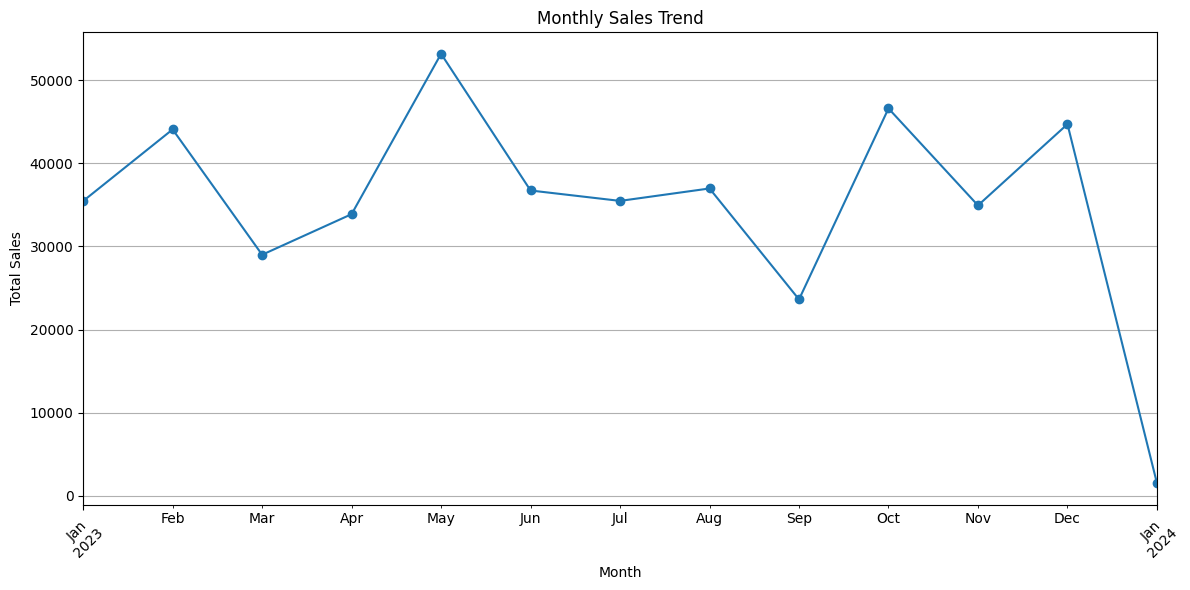

In [10]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

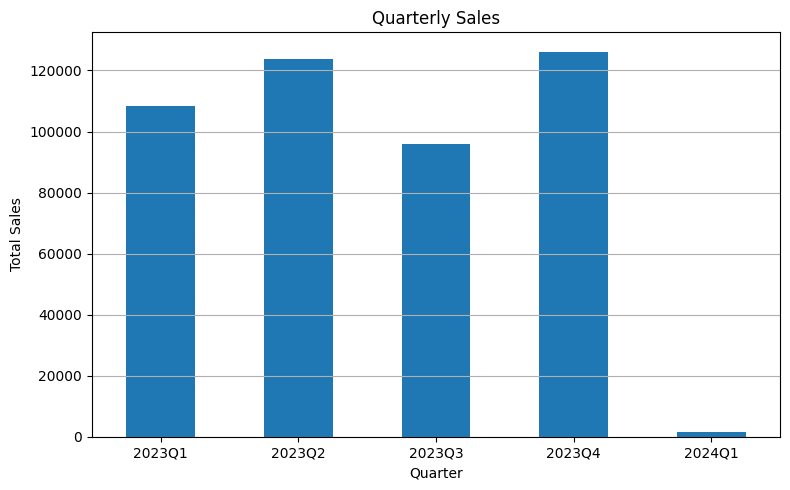

In [12]:
plt.figure(figsize=(8, 5))

quarterly_sales.plot(kind='bar')

plt.title('Quarterly Sales')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [13]:
gender_counts = df['Gender'].value_counts()

gender_counts

Female    510
Male      490
Name: Gender, dtype: int64

In [14]:
gender_counts = df['Gender'].value_counts()
gender_counts

Female    510
Male      490
Name: Gender, dtype: int64

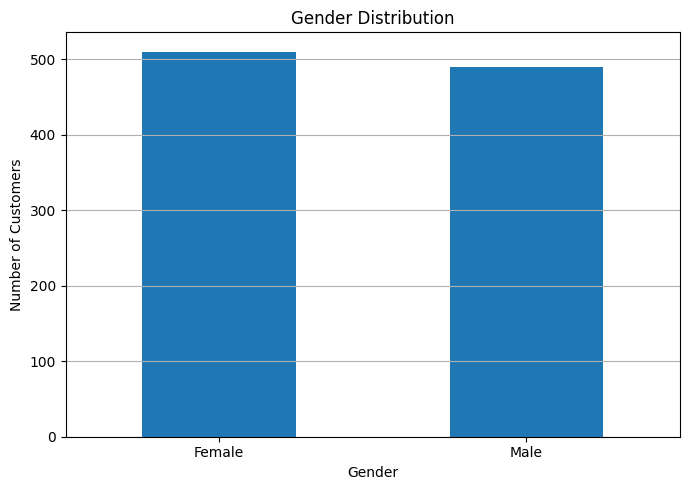

In [15]:
plt.figure(figsize=(7, 5))
gender_counts.plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [16]:
age_groups = pd.cut(
    df['Age'],
    bins=[0, 18, 25, 35, 45, 55, 100],
    labels=['Under 18', '18-25', '26-35', '36-45', '46-55', '56+']
)

age_group_counts = age_groups.value_counts().sort_index()
age_group_counts

Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56+         195
Name: Age, dtype: int64

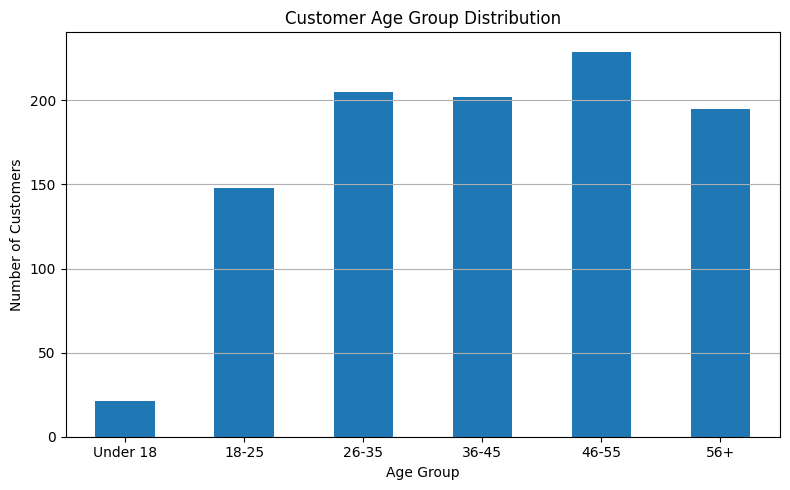

In [17]:
plt.figure(figsize=(8, 5))
age_group_counts.plot(kind='bar')
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [18]:
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
top_products

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

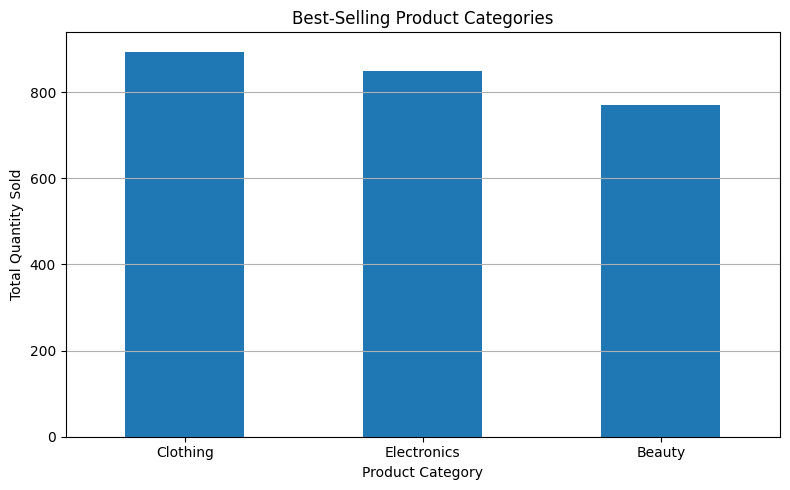

In [19]:
plt.figure(figsize=(8, 5))
top_products.plot(kind='bar')
plt.title('Best-Selling Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [20]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

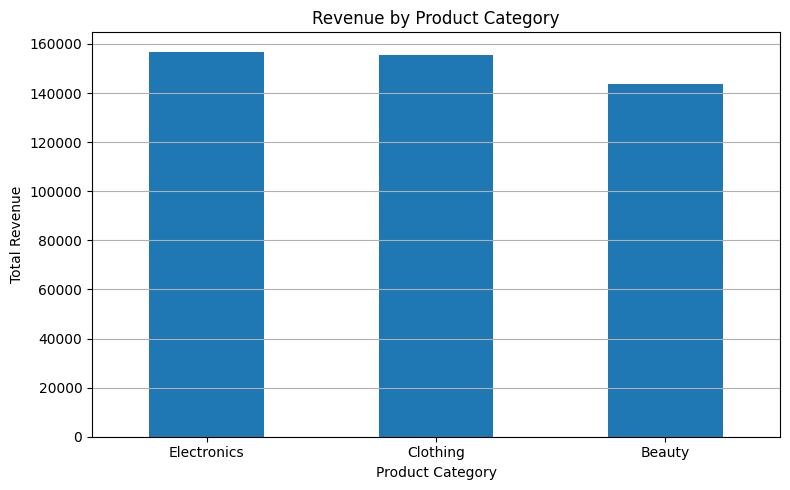

In [21]:
plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

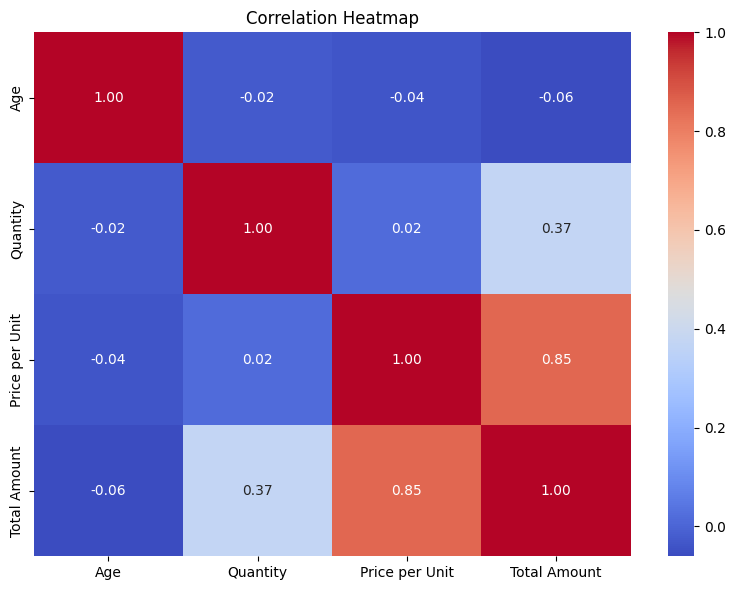

In [22]:
numeric_data = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]

correlation = numeric_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [23]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()
gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

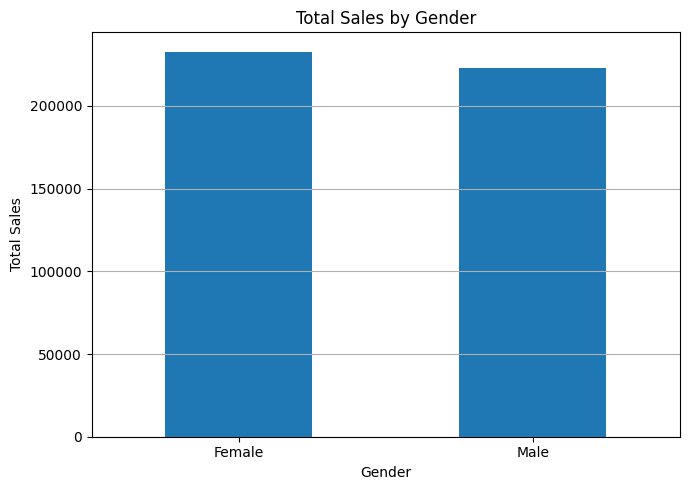

In [24]:
plt.figure(figsize=(7, 5))
gender_sales.plot(kind='bar')
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Observation
Monthly sales show fluctuations throughout the year. Sales were highest in May 2023, while September 2023 recorded the lowest sales among the complete months. The January 2024 value is much lower because the dataset ends on January 1, 2024, so it represents only a partial month.

### Observation
The gender distribution is nearly balanced, with 510 female customers and 490 male customers. Female customers represent a slightly larger share of the dataset.

### Observation

The 46-55 age group has the highest number of customers (229), followed by the 26-35 and 36-45 age groups. Customers under 18 represent the smallest group, with 21 customers.

### Observation

Clothing has the highest total quantity sold at 894 units, followed by Electronics with 849 units and Beauty with 771 units. This indicates that Clothing had the highest sales volume among the three product categories.

### Observation

Electronics generated the highest revenue at 156,905, followed by Clothing at 155,580 and Beauty at 143,515. Electronics therefore contributed the highest total revenue among the three categories.

### Observation

The heatmap shows the strength of relationships between the numerical variables. Quantity and Total Amount have a positive relationship, while Price per Unit and Total Amount also show a positive relationship. Age has relatively weak relationships with the other numerical variables.

### Observation

Female customers generated total sales of 232,840, while male customers generated 223,160. The difference is relatively small, indicating that sales were fairly balanced between the two gender groups.

## Conclusion

The exploratory data analysis provides useful insights into customer demographics, sales trends, and product category performance. Sales varied across different months and quarters, while the customer base was relatively balanced by gender. The analysis also shows differences in purchasing volume and revenue across product categories.

### Business Recommendations

1. **Focus on high-performing product categories:** Clothing had the highest quantity sold, while Electronics generated the highest revenue. The business can maintain sufficient stock and consider targeted promotions for these categories.

2. **Plan sales activities around monthly trends:** Sales varied considerably across months. The business can use these trends to plan inventory, promotions, and marketing campaigns during periods of higher and lower demand.

3. **Use customer demographics for targeted marketing:** The customer base includes several important age groups and has a nearly balanced gender distribution. Marketing campaigns can be tailored to different customer segments based on their purchasing patterns.

4. **Monitor product pricing and quantity:** The correlation analysis can help the business understand how quantity, price, and total sales are related and support better pricing and inventory decisions.